<a href="https://colab.research.google.com/github/aditya0589/notebooks/blob/main/AI%20Engineering/LangGraph/parallel_workflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional

In [28]:
class BatsmanState(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  strike_rate: Optional[float]
  boundary_percent: Optional[float]
  balls_per_boundary: Optional[float]
  summary: Optional[str]

In [29]:
# function to calculate strike_rate

def calculate_str(state: BatsmanState) -> BatsmanState:
  strike_rate = (state['runs'] / state['balls']) / 100

  return {'strike_rate': strike_rate}

In [30]:
# function to calculate balls per boundary

def calculate_bpb(state: BatsmanState) -> BatsmanState:
  bpb = state['balls'] / (state['fours'] + state['sixes'])

  return {'balls_per_boundary': bpb}

In [31]:
# function to calculate boundary percentage

def calculate_bp(state: BatsmanState) -> BatsmanState:
  bp = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100

  return {'boundary_percent': bp}

In [32]:
# summary

def summary(state: BatsmanState) -> BatsmanState:
  summary = f"""
  strike_rate: {state['strike_rate']},
  boundary_percent: {state['boundary_percent']},
  balls_per_boundary: {state['balls_per_boundary']}
  """

  return {'summary': summary}

In [33]:
graph = StateGraph(BatsmanState)

In [34]:
graph.add_node("calculate_str", calculate_str) # strike_rate
graph.add_node('calculate_bpb', calculate_bpb) # balls_per_boundary
graph.add_node('calculate_bp', calculate_bp) #boundary_percentage
graph.add_node('summary', summary) # summary

In [35]:
graph.add_edge(START, 'calculate_str')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_bp')

graph.add_edge('calculate_str', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_bp', 'summary')

graph.add_edge('summary', END)

In [36]:
workflow = graph.compile()

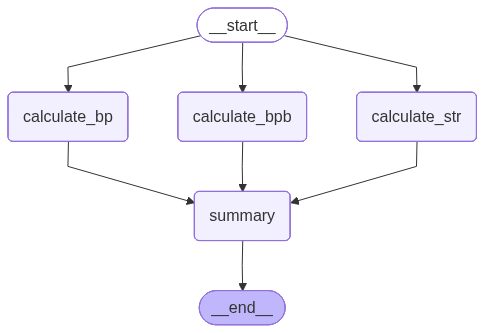

In [23]:
workflow

In [37]:
initial_state = {
    'runs': 40,
  'balls': 20,
  'fours': 6,
  'sixes': 4
}

output_state = workflow.invoke(initial_state)

print(output_state)

{'runs': 40, 'balls': 20, 'fours': 6, 'sixes': 4, 'strike_rate': 0.02, 'boundary_percent': 120.0, 'balls_per_boundary': 2.0, 'summary': '\n  strike_rate: 0.02,\n  boundary_percent: 120.0,\n  balls_per_boundary: 2.0\n  '}
